In [ ]:
# Install firebase-admin if not already
!pip install firebase-admin --quiet

In [ ]:
# Imports
import firebase_admin
from firebase_admin import credentials, db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.ensemble import IsolationForest
import seaborn as sns
import json

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
# # Upload the Firebase Admin SDK JSON file first manually in Colab
# from google.colab import files
# uploaded = files.upload()

# # Initialize Firebase
# cred = credentials.Certificate("your-firebase-adminsdk.json")  # Replace with actual filename
# firebase_admin.initialize_app(cred, {
#     'databaseURL': 'https://your-database-name.firebaseio.com/'  # Replace with your DB URL
# })


In [ ]:
# # Fetch last N entries (for example: last 100)
# ref = db.reference('sensor_data')  # Adjust according to your DB structure

# # Optional: Time filtering
# # You can customize the logic to pull only recent data using timestamps
# # For now, we take the latest 100 entries
# data_snapshot = ref.order_by_child('timestamp').limit_to_last(100).get()

# # Convert to DataFrame
# if data_snapshot:
#     firebase_df = pd.DataFrame(data_snapshot.values())
#     print("Data fetched from Firebase!")
# else:
#     firebase_df = pd.DataFrame()
#     print("No data found from Firebase.")

In [ ]:
# # Load it
# Healthdata = pd.read_csv("cattle_health_sample_data.csv")  # Replace with actual file name
# print("Static CSV loaded.")

# # Combine or choose one
# if not firebase_df.empty:
#     df = firebase_df.copy()
# else:
#     df = static_df.copy()

# print("Working with data shape:", df.shape)


# If the scenario is such that we are extracting data from Google Firebase then this code

In [ ]:
# Replace 'your-service-account-file.json' with your uploaded JSON key filename
cred = credentials.Certificate('cattleiotmonitoring-firebase-adminsdk-fbsvc-98a2a23831.json')

# Replace with your own database URL from Firebase console
firebase_admin.initialize_app(cred, {
    'databaseURL': "https://cattleiotmonitoring-default-rtdb.asia-southeast1.firebasedatabase.app"
})

In [ ]:
# Set the reference to the node where data is stored
ref = db.reference('sensor_data')

# Fetch the data from Firebase
data = ref.get()

# Preview the raw dictionary
print(data)


In [ ]:
# Convert to DataFrame
df = pd.DataFrame.from_dict(data, orient='index')  # 'index' because entry ID is key
df.reset_index(inplace=True)
df.rename(columns={'index': 'entry_id'}, inplace=True)

# Display the DataFrame
print(df)

In [ ]:
df = df.drop('entry_id', axis=1)
print(df)

In [ ]:
Healthdata = df

# If decided to use static data then this code

In [ ]:
Healthdata = pd.read_csv("cattle_health_sample_data_3.csv")

In [ ]:
Healthdata

,Serial No.,Temperature (C),Humidity (%),BPM,Longitude,Latitude,Timestamp,Alert Condition
0,1,39.2,64.6,71,84.905241,22.249966,2023-01-01 00:00:00,good
1,2,39.1,62.0,74,84.913380,22.248612,2023-01-01 00:01:00,good
2,3,37.2,50.5,54,84.908929,22.251448,2023-01-01 00:02:00,moderate
3,4,38.4,62.2,62,84.907345,22.251327,2023-01-01 00:03:00,good
4,5,39.0,54.0,70,84.904146,22.254330,2023-01-01 00:04:00,good
...,...,...,...,...,...,...,...,...
4495,4496,38.2,57.2,60,84.910203,22.251236,2023-01-04 02:55:00,good
4496,4497,38.1,55.7,71,84.907861,22.251592,2023-01-04 02:56:00,good
4497,4498,38.0,55.5,62,84.913271,22.249682,2023-01-04 02:57:00,good
4498,4499,38.7,64.7,60,84.912002,22.250816,2023-01-04 02:58:00,good


In [ ]:
# Preview the dataset
Healthdata.head()

,Serial No.,Temperature (C),Humidity (%),BPM,Longitude,Latitude,Timestamp,Alert Condition
0,1,39.2,64.6,71,84.905241,22.249966,2023-01-01 00:00:00,good
1,2,39.1,62.0,74,84.913380,22.248612,2023-01-01 00:01:00,good
2,3,37.2,50.5,54,84.908929,22.251448,2023-01-01 00:02:00,moderate
3,4,38.4,62.2,62,84.907345,22.251327,2023-01-01 00:03:00,good
4,5,39.0,54.0,70,84.904146,22.254330,2023-01-01 00:04:00,good


In [ ]:
print(Healthdata.isnull().sum())

Serial No.         0
Temperature (C)    0
Humidity (%)       0
BPM                0
Longitude          0
Latitude           0
Timestamp          0
Alert Condition    0
dtype: int64


In [ ]:
# 3. Encode categorical 'alert_condition'
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Healthdata['alert_condition_encoded'] = le.fit_transform(Healthdata['Alert Condition'])
print("Label Encoding Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label Encoding Mapping: {'critical': np.int64(0), 'good': np.int64(1), 'moderate': np.int64(2)}


In [ ]:
from sklearn.ensemble import IsolationForest

# Define features using exact column names
outlier_features = ['Temperature (C)', 'Humidity (%)', 'BPM', 'Longitude', 'Latitude']

# Apply Isolation Forest
Healthdata['outlier'] = IsolationForest(contamination=0.02, random_state=42).fit_predict(
    Healthdata[outlier_features]
)

# Filter out the outliers
Healthdata_clean = Healthdata[Healthdata['outlier'] == 1].copy()
Healthdata_clean.drop(columns=['outlier'], inplace=True)


In [ ]:
print("Final shape after outlier removal:", Healthdata_clean.shape)

Final shape after outlier removal: (4410, 9)


In [ ]:
df = Healthdata_clean.copy()

In [ ]:
df

,Serial No.,Temperature (C),Humidity (%),BPM,Longitude,Latitude,Timestamp,Alert Condition,alert_condition_encoded
0,1,39.2,64.6,71,84.905241,22.249966,2023-01-01 00:00:00,good,1
1,2,39.1,62.0,74,84.913380,22.248612,2023-01-01 00:01:00,good,1
2,3,37.2,50.5,54,84.908929,22.251448,2023-01-01 00:02:00,moderate,2
3,4,38.4,62.2,62,84.907345,22.251327,2023-01-01 00:03:00,good,1
4,5,39.0,54.0,70,84.904146,22.254330,2023-01-01 00:04:00,good,1
...,...,...,...,...,...,...,...,...,...
4495,4496,38.2,57.2,60,84.910203,22.251236,2023-01-04 02:55:00,good,1
4496,4497,38.1,55.7,71,84.907861,22.251592,2023-01-04 02:56:00,good,1
4497,4498,38.0,55.5,62,84.913271,22.249682,2023-01-04 02:57:00,good,1
4498,4499,38.7,64.7,60,84.912002,22.250816,2023-01-04 02:58:00,good,1


## FEATURE ENGINEERING

In [ ]:
# 1. Temperature-Humidity Index (THI)
df['THI'] = 0.8 * df['Temperature (C)'] + ((df['Humidity (%)'] / 100) * (df['Temperature (C)'] - 14.4)) + 46.4

In [ ]:
# 2. Resting Time Estimation
df['movement'] = np.sqrt(df['Latitude'].diff()**2 + df['Longitude'].diff()**2)
df['is_stationary'] = df['movement'] < 0.0001
df['resting_time'] = df['is_stationary'].astype(int).groupby(
    (df['is_stationary'] != df['is_stationary'].shift()).cumsum()
).cumsum() * 30  # assuming 30s interval

In [ ]:
# 3. Health Stability Score
df['temp_diff'] = df['Temperature (C)'].diff().abs()
df['bpm_diff'] = df['BPM'].diff().abs()
df['stability_score'] = 1 / (1 + df['temp_diff'] + df['bpm_diff'])

In [ ]:
# 4. Daily Health Summary (Optional EDA)
df['date'] = pd.to_datetime(df['Timestamp']).dt.date
daily_summary = df.groupby('date').agg({
    'Temperature (C)': ['mean', 'max', 'min'],
    'BPM': ['mean', 'max', 'min'],
    'Humidity (%)': 'mean'
})
print("Daily Summary Preview:")
print(daily_summary.head())

Daily Summary Preview:
           Temperature (C)                    BPM          Humidity (%)
                      mean   max   min       mean  max min         mean
date                                                                   
2023-01-01       38.574558  41.9  34.6  69.587986  114  30    59.896325
2023-01-02       38.614194  41.9  34.5  69.729595  118  30    59.841448
2023-01-03       38.616738  42.0  34.1  69.621277  119  30    60.256028
2023-01-04       38.572159  41.3  34.3  69.187500  117  30    60.070455


In [ ]:
# 5. Critical Alert Frequency
df['critical_alert'] = df['Alert Condition'].str.lower() == 'critical'
df['critical_alert_count'] = df.groupby('date')['critical_alert'].transform('sum')


In [ ]:
# 6. Movement Radius from Start
from geopy.distance import geodesic

start_point = (df.iloc[0]['Latitude'], df.iloc[0]['Longitude'])
df['distance_from_start'] = df.apply(
    lambda row: geodesic(start_point, (row['Latitude'], row['Longitude'])).meters, axis=1
)

In [ ]:
df

,Serial No.,Temperature (C),Humidity (%),BPM,Longitude,Latitude,Timestamp,Alert Condition,alert_condition_encoded,THI,movement,is_stationary,resting_time,temp_diff,bpm_diff,stability_score,date,critical_alert,critical_alert_count,distance_from_start
0,1,39.2,64.6,71,84.905241,22.249966,2023-01-01 00:00:00,good,1,93.7808,NaN,False,0,NaN,NaN,NaN,2023-01-01,False,32,0.000000
1,2,39.1,62.0,74,84.913380,22.248612,2023-01-01 00:01:00,good,1,92.9940,0.008251,False,0,0.1,3.0,0.243902,2023-01-01,False,32,852.288046
2,3,37.2,50.5,54,84.908929,22.251448,2023-01-01 00:02:00,moderate,2,87.6740,0.005278,False,0,1.9,20.0,0.043668,2023-01-01,False,32,414.040914
3,4,38.4,62.2,62,84.907345,22.251327,2023-01-01 00:03:00,good,1,92.0480,0.001589,False,0,1.2,8.0,0.098039,2023-01-01,False,32,264.090771
4,5,39.0,54.0,70,84.904146,22.254330,2023-01-01 00:04:00,good,1,90.8840,0.004388,False,0,0.6,8.0,0.104167,2023-01-01,False,32,496.254421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,4496,38.2,57.2,60,84.910203,22.251236,2023-01-04 02:55:00,good,1,90.5736,0.005822,False,0,0.7,9.0,0.093458,2023-01-04,False,5,530.483064
4496,4497,38.1,55.7,71,84.907861,22.251592,2023-01-04 02:56:00,good,1,90.0809,0.002369,False,0,0.1,11.0,0.082645,2023-01-04,False,5,324.539627
4497,4498,38.0,55.5,62,84.913271,22.249682,2023-01-04 02:57:00,good,1,89.8980,0.005738,False,0,0.1,9.0,0.099010,2023-01-04,False,5,828.379527
4498,4499,38.7,64.7,60,84.912002,22.250816,2023-01-04 02:58:00,good,1,93.0821,0.001702,False,0,0.7,2.0,0.270270,2023-01-04,False,5,703.305409


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4410 entries, 0 to 4499
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Serial No.               4410 non-null   int64  
 1   Temperature (C)          4410 non-null   float64
 2   Humidity (%)             4410 non-null   float64
 3   BPM                      4410 non-null   int64  
 4   Longitude                4410 non-null   float64
 5   Latitude                 4410 non-null   float64
 6   Timestamp                4410 non-null   object 
 7   Alert Condition          4410 non-null   object 
 8   alert_condition_encoded  4410 non-null   int64  
 9   THI                      4410 non-null   float64
 10  movement                 4409 non-null   float64
 11  is_stationary            4410 non-null   bool   
 12  resting_time             4410 non-null   int64  
 13  temp_diff                4409 non-null   float64
 14  bpm_diff                 4409

#1. 🧠 Heat Stress Impact: THI vs BPM (Scatter Plot)

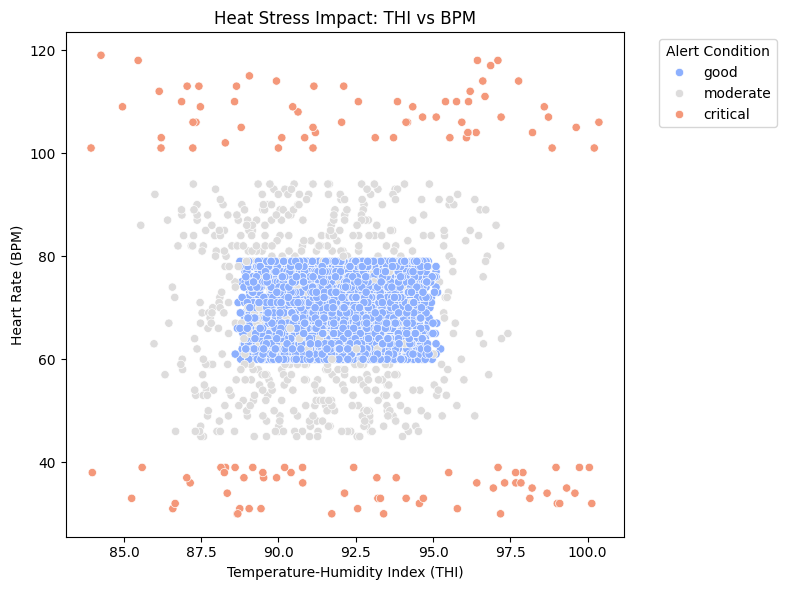

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='THI', y='BPM', hue='Alert Condition', palette='coolwarm')
plt.title("Heat Stress Impact: THI vs BPM")
plt.xlabel("Temperature-Humidity Index (THI)")
plt.ylabel("Heart Rate (BPM)")
plt.legend(title='Alert Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##  2. 📍 Movement Trail: Latitude vs Longitude with Time-Based Color Gradient

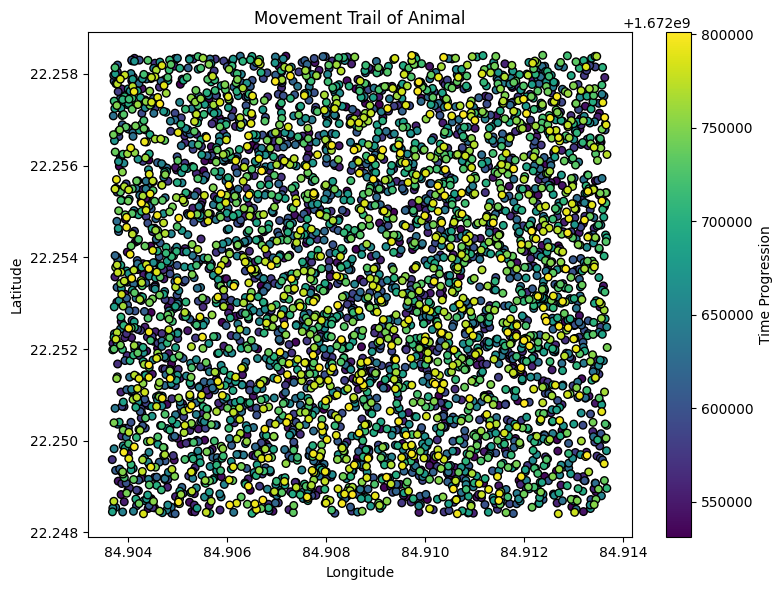

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Ensure Timestamp is datetime
df['Timestamp_dt'] = pd.to_datetime(df['Timestamp'])

# Normalize time for color gradient
timestamps = df['Timestamp_dt'].apply(lambda x: x.timestamp())
norm = mcolors.Normalize(vmin=timestamps.min(), vmax=timestamps.max())
cmap = cm.viridis

# Create scatter plot with color-mapped timestamps
plt.figure(figsize=(8,6))
sc = plt.scatter(df['Longitude'], df['Latitude'], c=timestamps, cmap=cmap, norm=norm, s=30, edgecolor='k')

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Time Progression')

plt.title("Movement Trail of Animal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


## 3. 📊 Daily Aggregated Health Summary (Multi-Line Plot)

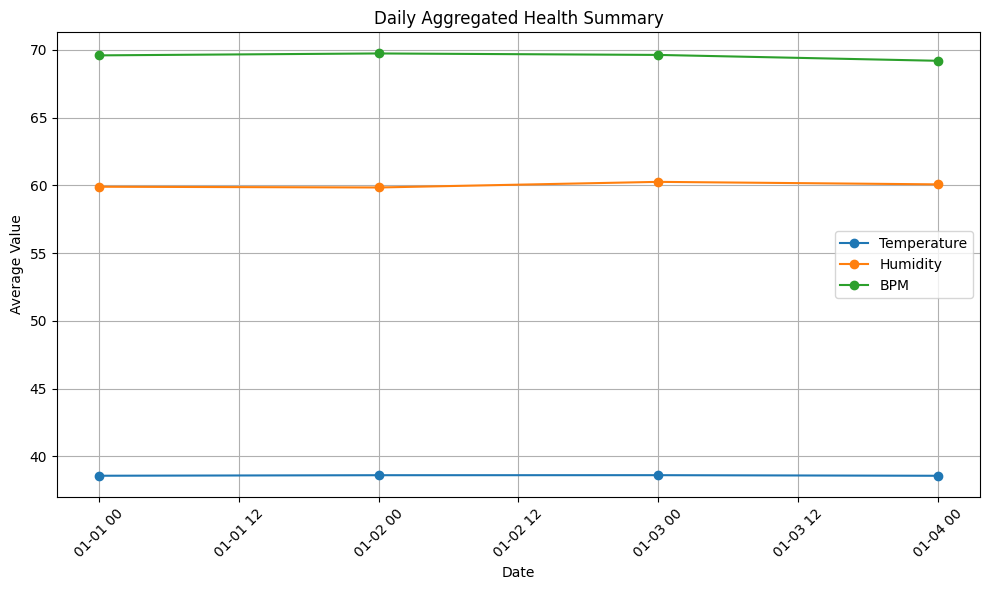

In [ ]:
daily_data = df.groupby('date')[['Temperature (C)', 'Humidity (%)', 'BPM']].mean().reset_index()

plt.figure(figsize=(10,6))
plt.plot(daily_data['date'], daily_data['Temperature (C)'], marker='o', label='Temperature')
plt.plot(daily_data['date'], daily_data['Humidity (%)'], marker='o', label='Humidity')
plt.plot(daily_data['date'], daily_data['BPM'], marker='o', label='BPM')
plt.title("Daily Aggregated Health Summary")
plt.xlabel("Date")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 4. 🌫️ Temperature vs Humidity Density Plot (2D KDE or Hexbin)

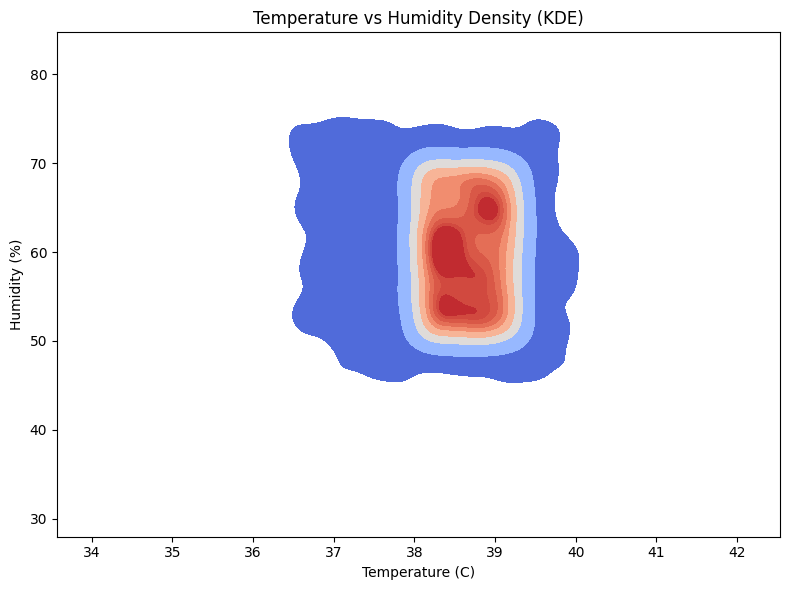

In [ ]:
plt.figure(figsize=(8,6))
sns.kdeplot(
    data=df, x="Temperature (C)", y="Humidity (%)",
    cmap="coolwarm", fill=True, thresh=0.05
)
plt.title("Temperature vs Humidity Density (KDE)")
plt.xlabel("Temperature (C)")
plt.ylabel("Humidity (%)")
plt.tight_layout()
plt.show()


## 4.2 - Using Hexbin

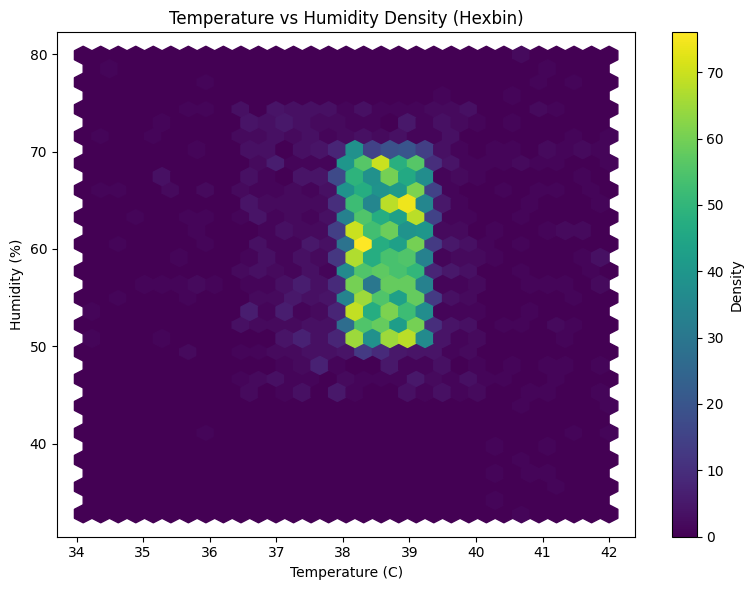

In [ ]:
plt.figure(figsize=(8,6))
plt.hexbin(df['Temperature (C)'], df['Humidity (%)'], gridsize=30, cmap='viridis')
plt.colorbar(label='Density')
plt.title("Temperature vs Humidity Density (Hexbin)")
plt.xlabel("Temperature (C)")
plt.ylabel("Humidity (%)")
plt.tight_layout()
plt.show()


## 5. 📈 Correlation Heatmap (Sensor + Engineered Features)

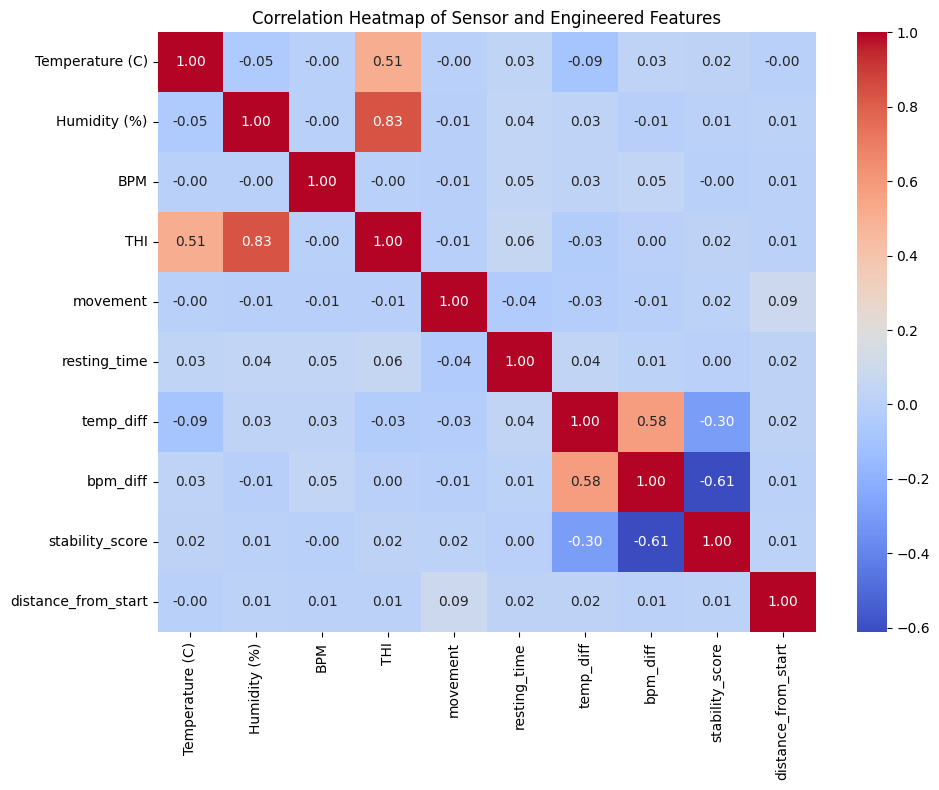

In [ ]:
plt.figure(figsize=(10,8))
correlation_features = [
    'Temperature (C)', 'Humidity (%)', 'BPM', 'THI', 'movement',
    'resting_time', 'temp_diff', 'bpm_diff', 'stability_score', 'distance_from_start'
]
corr = df[correlation_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Sensor and Engineered Features")
plt.tight_layout()
plt.show()


##  6. 🧮 Alert Condition Distribution (Count Plot / Pie Chart)

### Count Plot

<ipython-input-26-1e39669de035>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Alert Condition', palette='Set2')


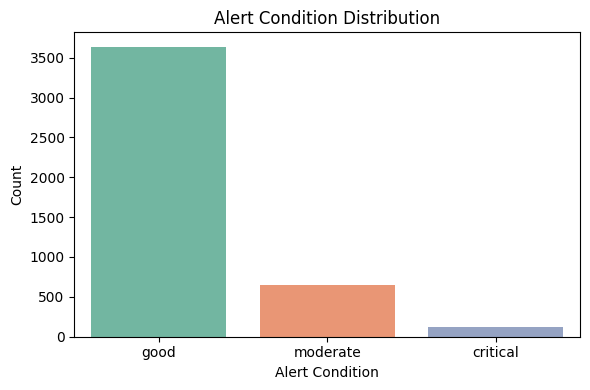

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Alert Condition', palette='Set2')
plt.title("Alert Condition Distribution")
plt.xlabel("Alert Condition")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Pie Chart

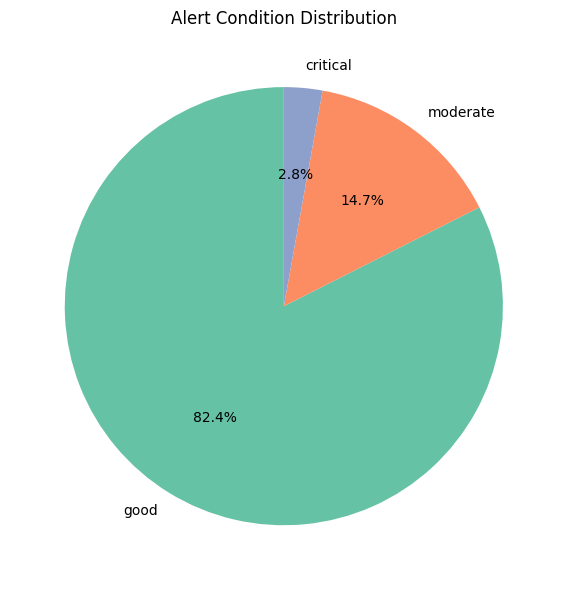

In [ ]:
plt.figure(figsize=(6,6))
df['Alert Condition'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
plt.title("Alert Condition Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

##7. 📏 Distance from Start Over Time (Line Plot)

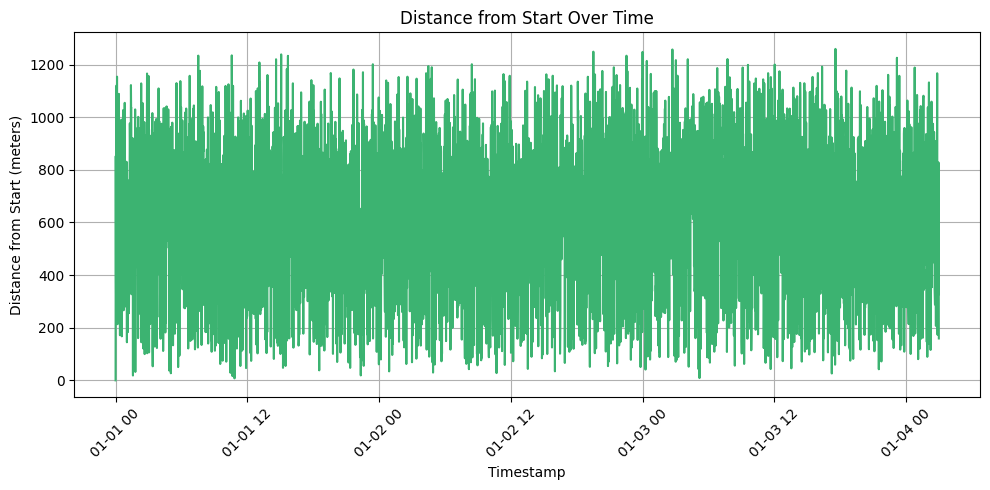

In [ ]:
df_sorted = df.sort_values(by='Timestamp_dt')

plt.figure(figsize=(10,5))
plt.plot(df_sorted['Timestamp_dt'], df_sorted['distance_from_start'], color='mediumseagreen')
plt.title("Distance from Start Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Distance from Start (meters)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


##8. 🚨 Alert Frequency Tracker (Bar Chart)

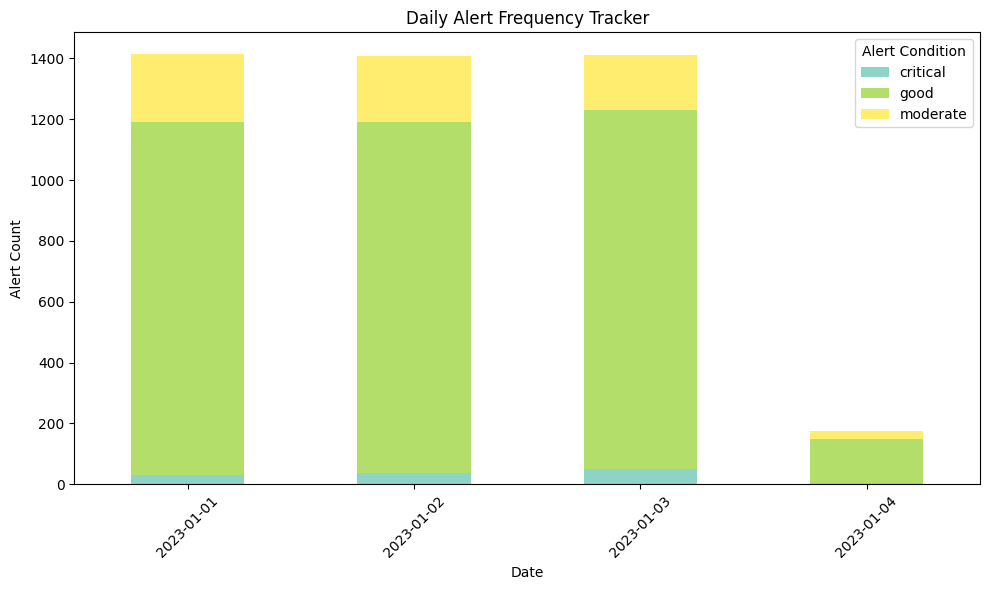

In [ ]:
alert_counts = df.groupby(['date', 'Alert Condition']).size().unstack(fill_value=0)

alert_counts.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set3')
plt.title("Daily Alert Frequency Tracker")
plt.xlabel("Date")
plt.ylabel("Alert Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


####  9. 📅 Daily Trends of Vital Signs

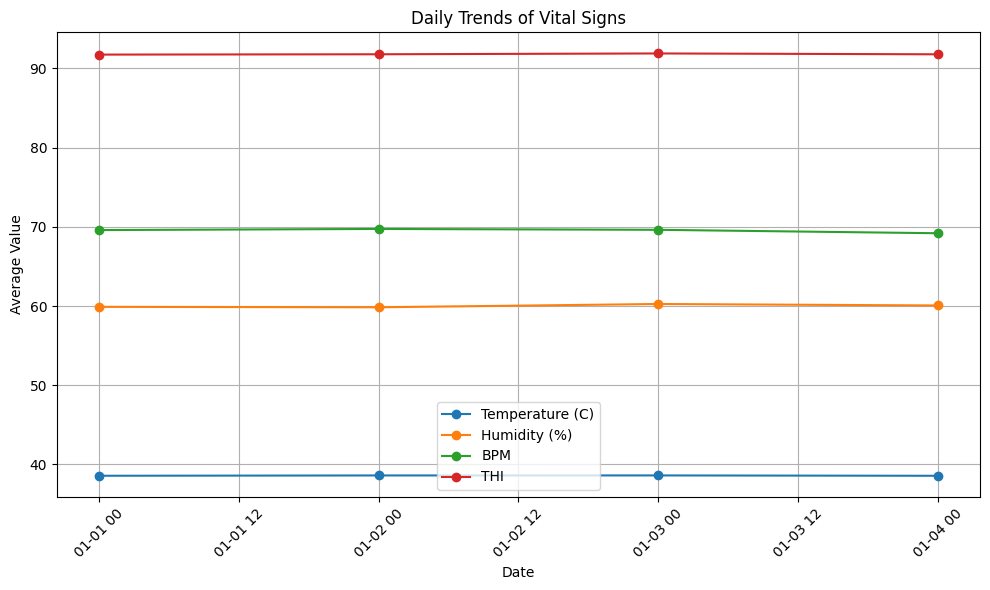

In [ ]:
daily_vitals = df.groupby('date')[['Temperature (C)', 'Humidity (%)', 'BPM', 'THI']].mean().reset_index()

plt.figure(figsize=(10,6))
for col in ['Temperature (C)', 'Humidity (%)', 'BPM', 'THI']:
    plt.plot(daily_vitals['date'], daily_vitals[col], marker='o', label=col)

plt.title("Daily Trends of Vital Signs")
plt.xlabel("Date")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Map-Based Visualizations

In [ ]:
import folium
from folium.plugins import MarkerCluster

# Step 1: Copy original data
df_unscaled = df.copy()

# Step 2: Extract starting coordinates
start_coords = (df_unscaled['Latitude'].iloc[0], df_unscaled['Longitude'].iloc[0])

# Step 3: Create map
m = folium.Map(location=start_coords, zoom_start=15)

# Step 4: Add path trail
coordinates = list(zip(df_unscaled['Latitude'], df_unscaled['Longitude']))
folium.PolyLine(locations=coordinates, color='blue', weight=3).add_to(m)

# Step 5: Add start and end markers
folium.Marker(coordinates[0], popup="Start", icon=folium.Icon(color='green')).add_to(m)
folium.Marker(coordinates[-1], popup="End", icon=folium.Icon(color='red')).add_to(m)

# Step 6: Display map
m


## Heatmap of Stationary vs. Active Locations

In [ ]:
import folium
from folium import plugins

df_unscaled = df.copy()
start_coords = (df_unscaled['Latitude'].iloc[0], df_unscaled['Longitude'].iloc[0])

# Get stationary coordinates
stationary_coords = df_unscaled[df_unscaled['is_stationary']][['Latitude', 'Longitude']].values.tolist()

# Create map
m_heat = folium.Map(location=start_coords, zoom_start=15)

# Add heatmap
heatmap = plugins.HeatMap(stationary_coords, radius=10)
m_heat.add_child(heatmap)

# Display map
m_heat


In [ ]:
m_heat.save("stationary_heatmap.html")

## Critical Alerts Geolocation Mapping

In [ ]:
from folium.plugins import MarkerCluster

df_unscaled = df.copy()
start_coords = (df_unscaled['Latitude'].iloc[0], df_unscaled['Longitude'].iloc[0])

# Create map
m_alerts = folium.Map(location=start_coords, zoom_start=15)

# Add marker cluster
marker_cluster = MarkerCluster().add_to(m_alerts)

# Plot critical alerts
for idx, row in df_unscaled[df_unscaled['critical_alert']].iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"🛑 Critical Alert\nBPM: {row['BPM']}\nTemp: {row['Temperature (C)']}",
        icon=folium.Icon(color='red')
    ).add_to(marker_cluster)

# Display map
m_alerts


#Habit/Pattern Recognition Visualizations

##Time-of-Day Alert Distribution (Bar Plot (Horizontal or Vertical))

In [ ]:
!pip install Plotly

In [ ]:

import pandas as pd
import plotly.express as px

# Convert timestamp to datetime and extract hour
df['hour'] = pd.to_datetime(df['Timestamp']).dt.hour

# Group by hour and count critical alerts
hourly_alert_count = df[df['critical_alert']].groupby('hour').size().reset_index(name='count')

# Plotly bar chart
fig = px.bar(
    hourly_alert_count,
    x='hour',
    y='count',
    title='Interactive Critical Alerts by Hour',
    labels={'hour': 'Hour of Day', 'count': 'Critical Alert Count'},
    color='count',
    color_continuous_scale='Reds'
)

fig.update_layout(
    xaxis=dict(tickmode='linear', dtick=1),
    plot_bgcolor='white',
    bargap=0.2,
    title_x=0.5
)

fig.show()


## Threshold-Based Health Stability Flags (Red Marker)

<ipython-input-37-2ed07647a4e0>:17: UserWarning:

Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.



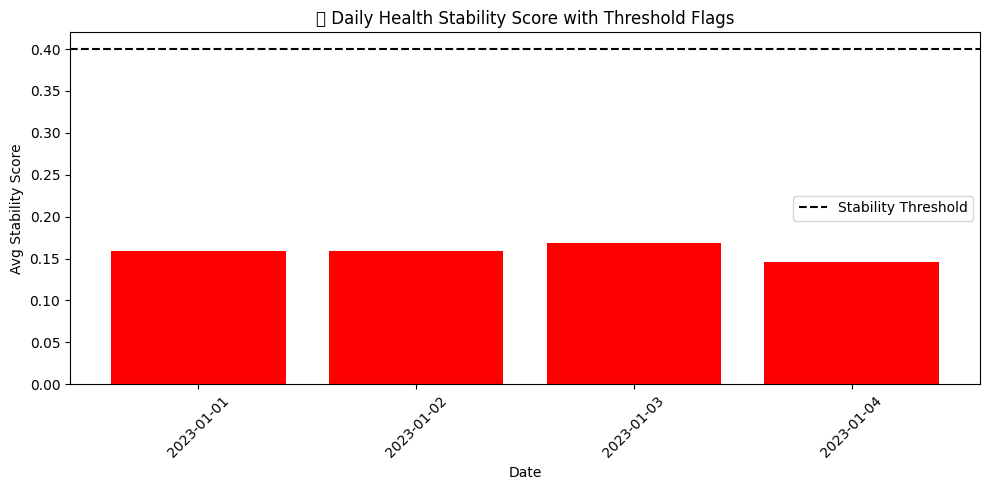

In [ ]:
# Set threshold
threshold = 0.4

# Daily mean stability score
daily_stability = df.groupby('date')['stability_score'].mean()
colors = ['red' if x < threshold else 'green' for x in daily_stability]

# Bar plot with color-coded flags
plt.figure(figsize=(10, 5))
plt.bar(daily_stability.index.astype(str), daily_stability.values, color=colors)
plt.axhline(y=threshold, color='black', linestyle='--', label='Stability Threshold')
plt.title('📉 Daily Health Stability Score with Threshold Flags')
plt.xlabel('Date')
plt.ylabel('Avg Stability Score')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4410 entries, 0 to 4499
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Serial No.               4410 non-null   int64         
 1   Temperature (C)          4410 non-null   float64       
 2   Humidity (%)             4410 non-null   float64       
 3   BPM                      4410 non-null   int64         
 4   Longitude                4410 non-null   float64       
 5   Latitude                 4410 non-null   float64       
 6   Timestamp                4410 non-null   object        
 7   Alert Condition          4410 non-null   object        
 8   alert_condition_encoded  4410 non-null   int64         
 9   THI                      4410 non-null   float64       
 10  movement                 4409 non-null   float64       
 11  is_stationary            4410 non-null   bool          
 12  resting_time             4410 non-null 

In [ ]:
type_counts = df['alert_condition_encoded'].value_counts()

print(type_counts)

alert_condition_encoded
1    3636
2     649
0     125
Name: count, dtype: int64


#Modelling

## MODEL 1 - Health State Classification (Multiclass Classification)
#### Model Type: XGBoost / LightGBM / Random Forest
#### Goal: Classify cattle into 3 or more health states like Healthy, Warning, Critical based on sensor data

In [ ]:
# 🧹 Step 1: Problem Definition – Health State Classification

# Display current unique values in the target column
print("Unique alert_condition_encoded values:", df['alert_condition_encoded'].unique())

health_state_map = {
    0: "Critical",
    1: "Healthy",
    2: "Warning"
}

# Create a new column 'Health_State' with mapped values
df['Health_State'] = df['alert_condition_encoded'].map(health_state_map)

# Confirm the mapping by checking the value counts
print(" Health State Distribution:")
print(df['Health_State'].value_counts())


Unique alert_condition_encoded values: [1 2 0]
 Health State Distribution:
Health_State
Healthy     3636
Warning      649
Critical     125
Name: count, dtype: int64


In [ ]:
# Sanity check – view sample rows
df[['Temperature (C)', 'Humidity (%)', 'BPM', 'THI', 'stability_score', 'Health_State']].head()

,Temperature (C),Humidity (%),BPM,THI,stability_score,Health_State
0,39.2,64.6,71,93.7808,NaN,Healthy
1,39.1,62.0,74,92.9940,0.243902,Healthy
2,37.2,50.5,54,87.6740,0.043668,Warning
3,38.4,62.2,62,92.0480,0.098039,Healthy
4,39.0,54.0,70,90.8840,0.104167,Healthy


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
# 1. Define selected features and target
selected_features = [
    'Temperature (C)', 'Humidity (%)', 'BPM', 'THI',
    'movement', 'resting_time', 'temp_diff', 'bpm_diff',
    'stability_score', 'distance_from_start', 'hour'
]

target_variable = 'alert_condition_encoded'

In [ ]:
# 2. Drop rows with missing values in selected features
df_model = df[selected_features + [target_variable]].dropna()

In [ ]:
# 3. Define feature matrix X and target y
X = df_model[selected_features]
y = df_model[target_variable]

In [ ]:
X

,Temperature (C),Humidity (%),BPM,THI,movement,resting_time,temp_diff,bpm_diff,stability_score,distance_from_start,hour
1,39.1,62.0,74,92.9940,0.008251,0,0.1,3.0,0.243902,852.288046,0
2,37.2,50.5,54,87.6740,0.005278,0,1.9,20.0,0.043668,414.040914,0
3,38.4,62.2,62,92.0480,0.001589,0,1.2,8.0,0.098039,264.090771,0
4,39.0,54.0,70,90.8840,0.004388,0,0.6,8.0,0.104167,496.254421,0
5,38.2,51.3,78,89.1694,0.008484,0,0.8,8.0,0.102041,1120.699297,0
...,...,...,...,...,...,...,...,...,...,...,...
4495,38.2,57.2,60,90.5736,0.005822,0,0.7,9.0,0.093458,530.483064,2
4496,38.1,55.7,71,90.0809,0.002369,0,0.1,11.0,0.082645,324.539627,2
4497,38.0,55.5,62,89.8980,0.005738,0,0.1,9.0,0.099010,828.379527,2
4498,38.7,64.7,60,93.0821,0.001702,0,0.7,2.0,0.270270,703.305409,2


In [ ]:
y

,alert_condition_encoded
1,1
2,2
3,1
4,1
5,1
...,...
4495,1
4496,1
4497,1
4498,1


In [ ]:
# 4. Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#5. Confirm shape and class balance
print("Shapes:")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print("\n Class Distribution in Training Set:")
print(y_train.value_counts())

Shapes:
X_train: (3527, 11), X_test: (882, 11)

 Class Distribution in Training Set:
alert_condition_encoded
1    2908
2     519
0     100
Name: count, dtype: int64


## Build & Evaluate the Health State Classification Model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Health State Mapping (for visualization)
health_state_map = {
    0: "Critical",
    1: "Healthy",
    2: "Warning"
}
health_state_labels = [health_state_map[i] for i in sorted(health_state_map.keys())]

In [ ]:
health_state_labels

['Critical', 'Healthy', 'Warning']

In [ ]:
# 1. Create Pipeline (Scaler + Model)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [ ]:
# 2. Fit the model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf', RandomForestClassifier(random_state=42))])

In [ ]:
#3. Predict
y_pred = pipeline.predict(X_test)

In [ ]:
# 4. Evaluation
print("🎯 Accuracy Score:", accuracy_score(y_test, y_pred))
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=health_state_labels))

🎯 Accuracy Score: 0.9784580498866213

📋 Classification Report:

              precision    recall  f1-score   support

    Critical       1.00      0.96      0.98        25
     Healthy       0.98      1.00      0.99       727
     Warning       0.99      0.86      0.92       130

    accuracy                           0.98       882
   macro avg       0.99      0.94      0.96       882
weighted avg       0.98      0.98      0.98       882



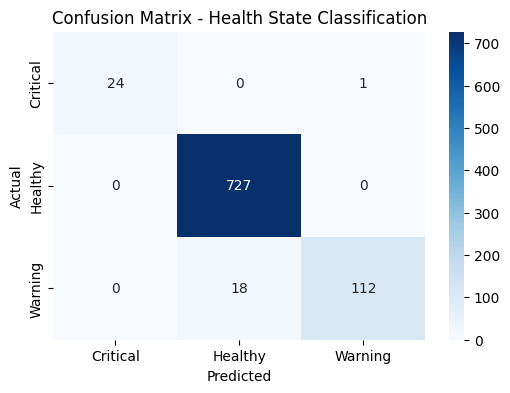

In [ ]:
#5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=health_state_labels, yticklabels=health_state_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Health State Classification")
plt.show()

## Some visualizations in context to the model trained

### 1. Feature Importance Plot (from Random Forest) - Visualize which features contribute most to the classification.

<ipython-input-58-28e48c4172b9>:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




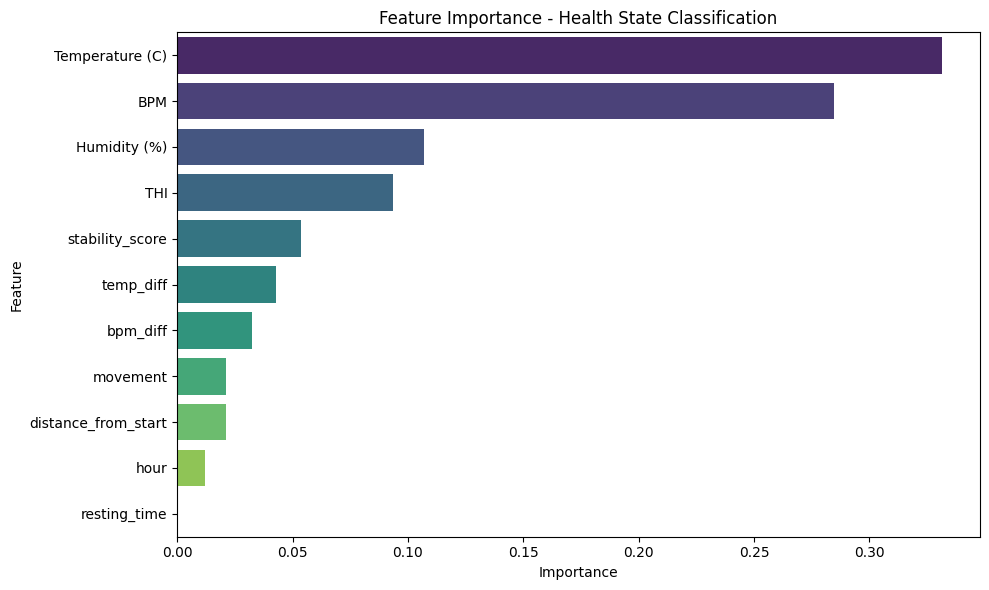

In [ ]:
importances = pipeline.named_steps['rf'].feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title("Feature Importance - Health State Classification")
plt.tight_layout()
plt.show()


## 2. Classification Report Heatmap

### Turning the precision, recall, and F1-score into a heatmap for quick comparison across classes.

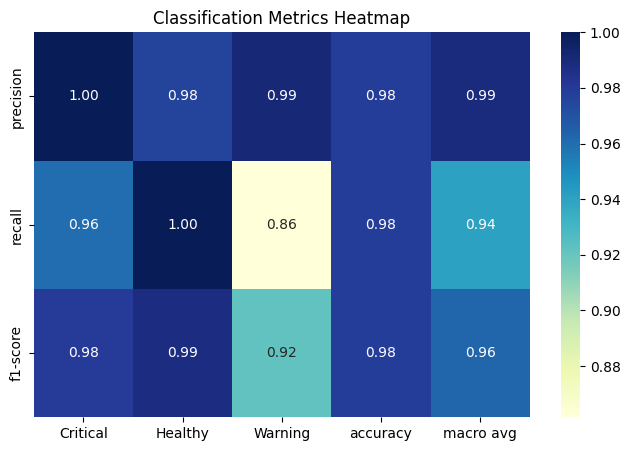

In [ ]:
report = classification_report(y_test, y_pred, target_names=health_state_labels, output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :-1]  # Exclude 'accuracy' and 'support' total

plt.figure(figsize=(8, 5))
sns.heatmap(report_df, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Classification Metrics Heatmap")
plt.show()


## 3. Prediction Confidence Histogram
### Plot the prediction probabilities to see how confident the model is.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names



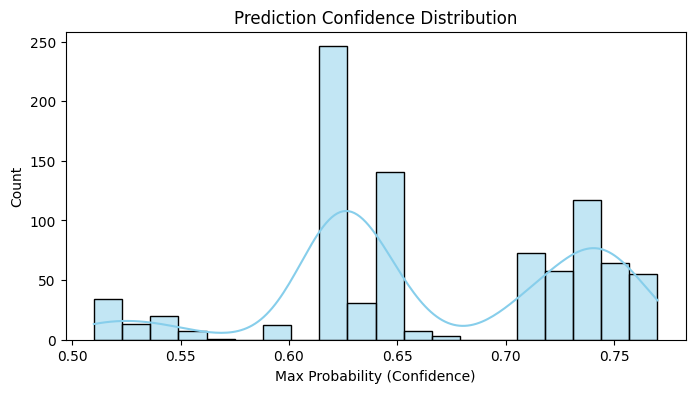

In [ ]:
probs = pipeline.named_steps['rf'].predict_proba(X_test)
max_probs = probs.max(axis=1)

plt.figure(figsize=(8, 4))
sns.histplot(max_probs, bins=20, kde=True, color='skyblue')
plt.title("Prediction Confidence Distribution")
plt.xlabel("Max Probability (Confidence)")
plt.ylabel("Count")
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Convert y_test and y_pred to Series (with matching index)
y_test_series = pd.Series(y_test, index=X_test.index)
y_pred_series = pd.Series(y_pred, index=X_test.index)

# Identify misclassified samples
misclassified_idx = (y_test_series != y_pred_series)

# Extract misclassified rows
misclassified_df = X_test[misclassified_idx].copy()
misclassified_df['Actual'] = y_test_series[misclassified_idx].map(health_state_map)
misclassified_df['Predicted'] = y_pred_series[misclassified_idx].map(health_state_map)

# Show top 5 misclassified examples
print("Top 5 Misclassified Samples:")
display(misclassified_df.head(5))


Top 5 Misclassified Samples:


,Temperature (C),Humidity (%),BPM,THI,movement,resting_time,temp_diff,bpm_diff,stability_score,distance_from_start,hour,Actual,Predicted
1166,38.3,58.9,60,91.1171,0.005539,0,0.7,19.0,0.048309,755.894068,19,Warning,Healthy
88,35.2,67.8,30,88.6624,0.004493,0,0.8,7.0,0.113636,683.329771,1,Critical,Warning
681,38.2,66.9,75,92.8822,0.008910,0,0.0,2.0,0.333333,138.532258,11,Warning,Healthy
948,38.0,68.9,74,93.0604,0.001267,0,0.1,4.0,0.196078,850.607634,15,Warning,Healthy
1737,38.3,51.2,71,89.2768,0.004168,0,0.1,7.0,0.123457,748.810358,4,Warning,Healthy


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4410 entries, 0 to 4499
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Serial No.               4410 non-null   int64         
 1   Temperature (C)          4410 non-null   float64       
 2   Humidity (%)             4410 non-null   float64       
 3   BPM                      4410 non-null   int64         
 4   Longitude                4410 non-null   float64       
 5   Latitude                 4410 non-null   float64       
 6   Timestamp                4410 non-null   object        
 7   Alert Condition          4410 non-null   object        
 8   alert_condition_encoded  4410 non-null   int64         
 9   THI                      4410 non-null   float64       
 10  movement                 4409 non-null   float64       
 11  is_stationary            4410 non-null   bool          
 12  resting_time             4410 non-null 

# Model 2 - Anomaly Detection (Isolation Forest)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
features = [
    'Temperature (C)', 'Humidity (%)', 'THI', 'BPM',
    'movement', 'resting_time', 'temp_diff', 'bpm_diff',
    'stability_score'
]

df_anomaly = df[features].copy()

# Optional: Handle missing values (drop or impute)
df_anomaly.dropna(inplace=True)  # you could use fillna(method='ffill') instead if needed


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_anomaly)


In [ ]:
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(X_scaled)

IsolationForest(contamination=0.05, random_state=42)

In [ ]:
anomaly_scores = iso_forest.decision_function(X_scaled)
anomalies = iso_forest.predict(X_scaled)

# Attach back to dataframe
df_anomaly['anomaly_score'] = anomaly_scores
df_anomaly['anomaly_label'] = anomalies  # -1 = anomaly, 1 = normal

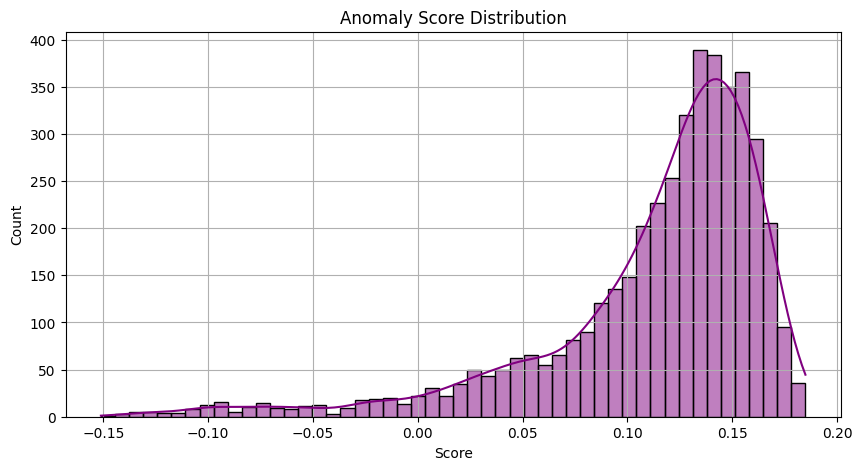

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df_anomaly['anomaly_score'], bins=50, kde=True, color='purple')
plt.title('Anomaly Score Distribution')
plt.xlabel('Score')
plt.grid(True)
plt.show()

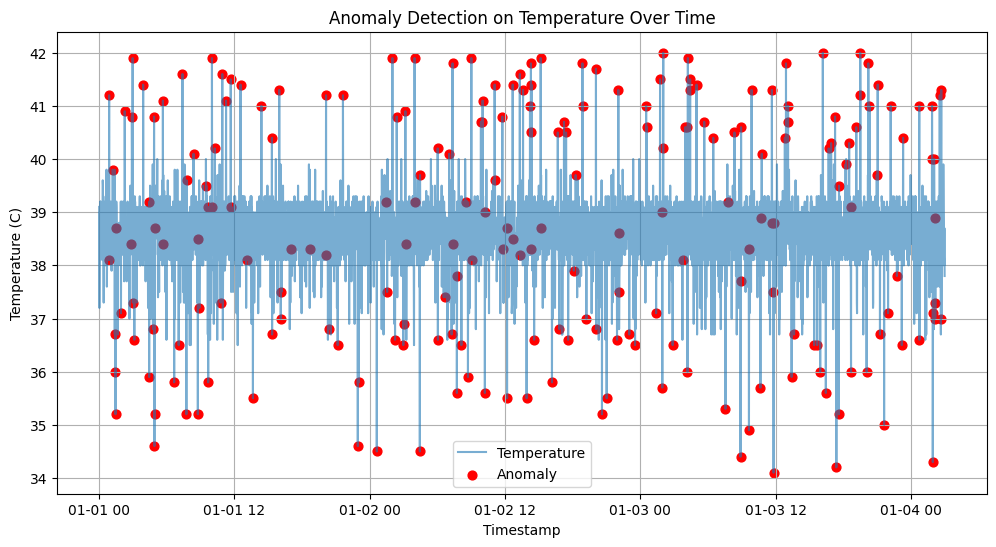

In [ ]:
# Merge back to original dataframe with timestamps
df_combined = df.copy()
df_combined = df_combined.loc[df_anomaly.index]
df_combined['anomaly'] = anomalies

plt.figure(figsize=(12, 6))
plt.plot(df_combined['Timestamp_dt'], df_combined['Temperature (C)'], label='Temperature', alpha=0.6)
plt.scatter(df_combined[df_combined['anomaly'] == -1]['Timestamp_dt'],
            df_combined[df_combined['anomaly'] == -1]['Temperature (C)'],
            color='red', label='Anomaly', s=40)
plt.legend()
plt.title('Anomaly Detection on Temperature Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Temperature (C)')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Map predicted labels (-1 = anomaly → 1, 1 = normal → 0)
df_combined['predicted_anomaly'] = df_combined['anomaly'].map({1: 0, -1: 1})

# Map actual critical health states to 1/0 (optional baseline)
df_combined['actual_health_issue'] = df_combined['Health_State'].apply(lambda x: 1 if x == 'Critical' else 0)

# Evaluate
print(confusion_matrix(df_combined['actual_health_issue'], df_combined['predicted_anomaly']))
print(classification_report(df_combined['actual_health_issue'], df_combined['predicted_anomaly']))

[[4188   96]
 [   0  125]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      4284
           1       0.57      1.00      0.72       125

    accuracy                           0.98      4409
   macro avg       0.78      0.99      0.86      4409
weighted avg       0.99      0.98      0.98      4409



In [ ]:
df['rolling_bpm'] = df['BPM'].rolling(window=6).mean()
df['rolling_temp'] = df['Temperature (C)'].rolling(window=6).mean()

## trail case

In [ ]:
import pandas as pd

# Select the necessary features
features = [
    'Temperature (C)', 'Humidity (%)', 'THI', 'BPM',
    'movement', 'resting_time',
    'stability_score', 'temp_diff', 'bpm_diff',
    'hour'
]

df_anomaly = df[features].copy()

# Drop missing values
df_anomaly.dropna(inplace=True)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_anomaly)


In [ ]:
from sklearn.ensemble import IsolationForest

# Instantiate and fit the model
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(X_scaled)

# Predict anomalies (-1 = anomaly, 1 = normal)
anomaly_labels = iso_forest.predict(X_scaled)
df_anomaly['anomaly'] = anomaly_labels


In [ ]:
# Count anomalies
print(df_anomaly['anomaly'].value_counts())

# Add to original df for visualization if needed
df['anomaly_iso'] = -1  # Default
df.loc[df_anomaly.index, 'anomaly_iso'] = df_anomaly['anomaly']


anomaly
 1    4188
-1     221
Name: count, dtype: int64


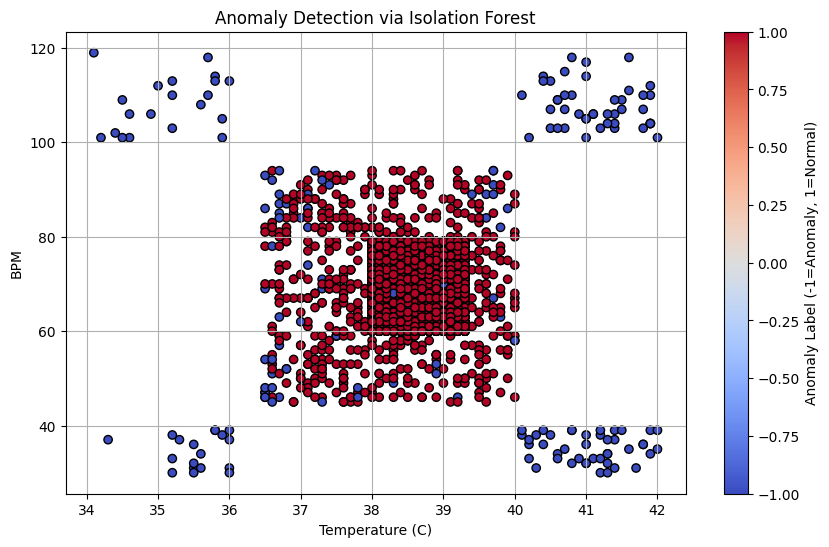

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_anomaly['Temperature (C)'], df_anomaly['BPM'],
            c=df_anomaly['anomaly'], cmap='coolwarm', edgecolor='k')
plt.xlabel('Temperature (C)')
plt.ylabel('BPM')
plt.title('Anomaly Detection via Isolation Forest')
plt.grid(True)
plt.colorbar(label='Anomaly Label (-1=Anomaly, 1=Normal)')
plt.show()


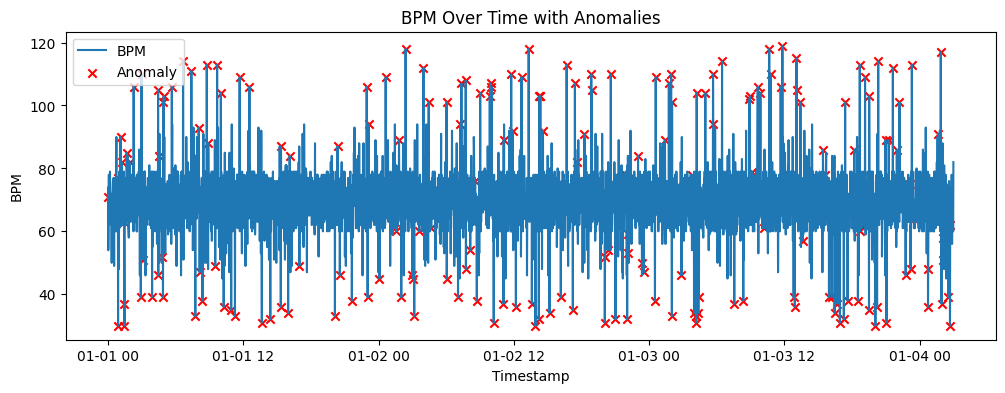

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df['Timestamp_dt'], df['BPM'], label='BPM')
plt.scatter(df[df['anomaly_iso'] == -1]['Timestamp_dt'],
            df[df['anomaly_iso'] == -1]['BPM'],
            color='red', label='Anomaly', marker='x')
plt.legend()
plt.title('BPM Over Time with Anomalies')
plt.xlabel('Timestamp')
plt.ylabel('BPM')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Convert to binary for comparison
true_labels = df.loc[df_anomaly.index, 'critical_alert'].astype(int)
pred_labels = (df_anomaly['anomaly'] == -1).astype(int)

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(true_labels, pred_labels))


Confusion Matrix:
 [[4188   96]
 [   0  125]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      4284
           1       0.57      1.00      0.72       125

    accuracy                           0.98      4409
   macro avg       0.78      0.99      0.86      4409
weighted avg       0.99      0.98      0.98      4409

